<a href="https://colab.research.google.com/github/Abeldb11/Ahadu/blob/main/PCN4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
 # "Downloading important libraries that I'm gonna use later"
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time, math

DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # This gives freedome
print(f"PyTorch: {torch.__version__}\n")

PyTorch: 2.11.0+cu128



In [21]:
class PCLayer(nn.Module):

    def __init__(self, below_dim: int, above_dim: int, activation=F.gelu):
        super().__init__()
        self.W          = nn.Linear(above_dim, below_dim)
        self.activation = activation
        self.log_precision = nn.Parameter(torch.zeros(1))   # init: precision=1
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)

    @property
    def precision(self) -> torch.Tensor:                      # this is to make the precision positive and regularize or clamp for numerical stability
        return self.log_precision.exp().clamp(0.1, 20.0)

    def predict(self, x_above: torch.Tensor) -> torch.Tensor:# It implements the actual task that it predicts based on the imput and wwight from above.
        return self.activation(self.W(x_above))

In [22]:
class PCRNNNet(nn.Module):
    """
    Predictive Coding over a 3-layer stacked Vanilla RNN.

    The RNN processes MNIST row-by-row (28 time-steps × 28 pixels).
    PC inference then refines the final hidden states h1, h2, h3 to
    minimise free energy, with the class label y clamped during training.

    Parameters
    ──────────
    hidden_sizes        hidden dim for each of the 3 RNN layers
    inference_lr        step size for latent gradient descent
    n_inference_steps   T (must satisfy T ≥ 3 × n_rnn_layers)
    ce_weight           weight on cross-entropy encoder loss
    pc_weight           weight on PC free-energy loss
    """

    def __init__(self,
                 input_size:    int   = 28, # the size of one row
                 hidden_sizes:  list  = [256, 128, 64], # we have a three layers and those numbers are their dimentions
                 n_classes:     int   = 10,  # final y layer
                 inference_lr:  float = 0.05, # this is the learning rate we use during the inference loop
                 n_inference_steps: int = 50, # the number of inference steps
                 ce_weight:     float = 1.0,   #it's the weight we give for cross entropy loss
                 pc_weight:     float = 0.5):  #it's the wight for the free energy loss of predictive cod
        super().__init__()

        assert n_inference_steps >= 3 * len(hidden_sizes), (
            f"T={n_inference_steps} must be ≥ 3×{len(hidden_sizes)}={3*len(hidden_sizes)}"
        )

        self.hidden_sizes      = hidden_sizes
        self.n_rnn_layers      = len(hidden_sizes)       # 3
        self.n_pc_connections  = len(hidden_sizes)       # 3  (one per RNN layer + y→h3)
        self.inference_lr      = inference_lr
        self.n_inference_steps = n_inference_steps
        self.ce_weight         = ce_weight
        self.pc_weight         = pc_weight

        # RNN encoder; it initialize the internal state (h1,h2, h3) based on the input features, uses non-linear func tanh, the rnn has 3 layers,
        self.rnn1 = nn.RNN(input_size,        hidden_sizes[0],
                           batch_first=True,  nonlinearity='tanh')
        self.rnn2 = nn.RNN(hidden_sizes[0],   hidden_sizes[1],
                           batch_first=True,  nonlinearity='tanh')
        self.rnn3 = nn.RNN(hidden_sizes[1],   hidden_sizes[2],
                           batch_first=True,  nonlinearity='tanh')


        node_dims = hidden_sizes + [n_classes]   # [256, 128, 64, 10], this buildis link between the heirarchical layers
        self.pc_layers = nn.ModuleList([
            PCLayer(node_dims[i], node_dims[i + 1])
            for i in range(len(node_dims) - 1)
        ])

        # Classification, it establishes a connection from h3 to y, and help us to start with the initial prediction of class label, it also carry the entropy loss
        self.classifier = nn.Linear(hidden_sizes[2], n_classes)
        nn.init.xavier_uniform_(self.classifier.weight) # xavier initialization scales the starting weights based on the input and output dimensions of that layer

    # ── helpers ────────────────────────────────────────────────────────────────

    def _rnn_encode(self, x: torch.Tensor):
        """
        These acts/helps as the  initial hypotheses for the predictive coding loop
        Bottom-up RNN pass.
        x : [B, 28, 28]  (batch, time-steps, features)
        Returns h1, h2, h3 : final hidden states [B, dim] — still on graph.
        """
        out1, h1 = self.rnn1(x)           # out1: [B,28,256]
        out2, h2 = self.rnn2(out1)         # out2: [B,28,128]
        _,    h3 = self.rnn3(out2)         # h3:   [1,B,64]


        h1 = h1.squeeze(0)                 # [B, 256]
        h2 = h2.squeeze(0)                 # [B, 128]
        h3 = h3.squeeze(0)                 # [B,  64]
        return h1, h2, h3

    def _compute_errors(self, latents: list, y: torch.Tensor) -> list:

        nodes = latents + [y]              # the difference b/n actual lower states and top-down predictions, [h1, h2, h3, y]
        return [nodes[l] - self.pc_layers[l].predict(nodes[l + 1])
                for l in range(len(self.pc_layers))]

    def _free_energy(self, errors: list) -> torch.Tensor: # calculates the total scalar free energy

        F = torch.zeros(1, device=next(self.parameters()).device).squeeze()
        for e, pc_l in zip(errors, self.pc_layers):
            F = F + pc_l.precision * 0.5 * (e ** 2).mean()
        return F

    def _metrics_from_errors(self, errors: list) -> dict:
        """
        Compute per-layer diagnostics from a list of error tensors.
        Returns dict with per-layer energies, norms, and precisions.
        """
        layer_names = ["h2→h1", "h3→h2", "y→h3"]
        metrics = {}
        for i, (e, pc_l) in enumerate(zip(errors, self.pc_layers)):
            name = layer_names[i]
            metrics[f"F_{name}"]   = (pc_l.precision * 0.5 * (e**2).mean()).item()
            metrics[f"E_{name}"] = e.detach().norm(dim=-1).mean().item()
            metrics[f"σ⁻²_{name}"] = pc_l.precision.item()
        metrics["F_total"] = sum(v for k, v in metrics.items() if k.startswith("F_"))
        return metrics

    #  PC inference loop

    def _inference_loop(self,
                        h1_init: torch.Tensor,
                        h2_init: torch.Tensor,
                        h3_init: torch.Tensor,
                        target:  torch.Tensor = None,
                        track_every: int      = 0) -> tuple:
        """
        note that not to forget is
          PC Inference — T gradient-descent steps on free energy F.

          during Training
            y  = one-hot target  (CLAMPED, not updated)
            h1, h2, h3 are FREE (updated for T steps) so that they bridge the gap between what the image looks like and what the target label demands.

        Testing (target = None):
        h1, h2, h3, y are all FREE
        argmax(y) after convergence = predicted class




        f0             : F at step 0  before any updates
        fT             : F at step T  after convergence
        """
        # Warm-start latents from RNN encoder (detached — no grad for RNN here)
        h1 = h1_init.detach().clone()
        h2 = h2_init.detach().clone()
        h3 = h3_init.detach().clone()

        # Warm-start y from classifier head
        with torch.no_grad():
            y = self.classifier(h3).clone()

        # Clamp y if supervised
        if target is not None:
            y = target.clone().detach()

        latents  = [h1, h2, h3]
        y_is_free = (target is None)

        conv_curve = []
        f0, fT     = None, None

        for step in range(self.n_inference_steps):

            # Attach gradients to free variables
            for i in range(3):
                latents[i] = latents[i].detach().requires_grad_(True)
            if y_is_free:
                y = y.detach().requires_grad_(True)

            with torch.enable_grad():
                errors = self._compute_errors(latents, y)


                F_val = sum(
                    pc_l.precision.detach() * 0.5 * (e ** 2).mean()
                    for e, pc_l in zip(errors, self.pc_layers)
                )

                free_vars = list(latents)
                if y_is_free:
                    free_vars = free_vars + [y]

                grads = torch.autograd.grad(F_val, free_vars, create_graph=False)

            # Recording convergence metrics
            f_val_item = F_val.item()
            if step == 0:
                f0 = f_val_item
            if step == self.n_inference_steps - 1:
                fT = f_val_item
            if track_every > 0 and step % track_every == 0:
                conv_curve.append((step, f_val_item))

            # Gradient-descent step (clipped for stability)
            with torch.no_grad():
                for i, g in enumerate(grads[:3]):
                    latents[i] = latents[i] - self.inference_lr * g.clamp(-1.0, 1.0)
                if y_is_free:
                    g_y = grads[3]
                    y   = y - self.inference_lr * g_y.clamp(-1.0, 1.0)

        return ([l.detach() for l in latents],
                y.detach(),
                conv_curve, f0, fT)

    # ── forward (train) ────────────────────────────────────────────────────────

    def forward(self,
                x:       torch.Tensor,
                target:  torch.Tensor = None,
                labels:  torch.Tensor = None,
                track_every: int      = 0) -> dict:
        """
        Full training forward pass.

        Returns a dict with all losses and diagnostic metrics.
        """
        # ── Phase 1: RNN encoding (warm start + CE loss) ──────────────────────
        h1_rnn, h2_rnn, h3_rnn = self._rnn_encode(x)   # still on graph
        y_rnn   = self.classifier(h3_rnn)                # [B, 10]

        ce_loss = (F.cross_entropy(y_rnn, labels)
                   if labels is not None
                   else torch.zeros(1, device=x.device).squeeze())

        # ── Phase 2: PC inference (latents minimise F, weights frozen) ─────────
        settled_h, settled_y, conv_curve, f0, fT = self._inference_loop(
            h1_rnn, h2_rnn, h3_rnn,
            target      = target,
            track_every = track_every,
        )

        # ── Phase 3: Weight update — recompute errors with grad ─────────────────
        # Latents are detached → gradient flows only through W_gen and precisions
        errors  = self._compute_errors(settled_h, settled_y)
        pc_loss = self._free_energy(errors)

        # ── Combine ────────────────────────────────────────────────────────────
        total_loss = self.pc_weight * pc_loss + self.ce_weight * ce_loss

        # ── Diagnostics ────────────────────────────────────────────────────────
        with torch.no_grad():
            metrics = self._metrics_from_errors(errors)
            metrics["pc_loss"]   = pc_loss.item()
            metrics["ce_loss"]   = ce_loss.item()
            metrics["total_loss"]= total_loss.item()
            metrics["F0"]        = f0
            metrics["FT"]        = fT
            metrics["ratio"]     = (fT / f0) if (f0 and f0 > 0) else 1.0
            metrics["conv_curve"]= conv_curve

        return total_loss, metrics

    # ── predict (test) ─────────────────────────────────────────────────────────

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        """
        Test-time prediction.
        Runs PC inference with no clamping; returns settled y as class logits.
        """
        self.eval()
        with torch.no_grad():
            h1, h2, h3 = self._rnn_encode(x)

        settled_h, settled_y, _, _, _ = self._inference_loop(
            h1, h2, h3, target=None, track_every=0
        )
        return settled_y   # [B, 10]


# Data

def get_loaders(batch_size: int = 256):
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
        # Keep as [28, 28] — RNN will see 28 time-steps of 28 features
    ])
    train_ds = datasets.MNIST("./data", train=True,  download=True, transform=tf) # the training and test set is classified train=True and train=False. I mean it is predifined by yan lecunn in the internal metadata of the download files
    test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tf)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=512,       shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, test_loader


def to_onehot(labels: torch.Tensor, n: int = 10) -> torch.Tensor:
    oh = torch.zeros(labels.size(0), n, device=labels.device)
    oh.scatter_(1, labels.unsqueeze(1), 1.0)
    return oh

In [23]:
def train_epoch(model, loader, opt, epoch, # this fun manages a single complete pass (one epoch) through the training dataset.
                log_every=50, track_conv_every=100):
    model.train()
    epoch_metrics = {
        "total_loss": [], "pc_loss": [], "ce_loss": [],
        "F_total": [], "ratio": [],
        "F_h2→h1": [], "F_h3→h2": [], "F_y→h3": [],
        "E_h2→h1": [], "E_h3→h2": [], "E_y→h3": [],
    }
    conv_snapshots = []   # for convergence curve plot
    t0 = time.time()

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs   = imgs.squeeze(1).to(DEVICE)
        labels = labels.to(DEVICE)
        target = to_onehot(labels)


        track = track_conv_every if batch_idx % track_conv_every == 0 else 0

        opt.zero_grad()
        total_loss, metrics = model(imgs, target=target, labels=labels,
                                    track_every=track)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()

        # Accumulating metrics
        for k in epoch_metrics:
            if k in metrics:
                epoch_metrics[k].append(metrics[k])

        if metrics.get("conv_curve"):
            conv_snapshots.append(metrics["conv_curve"])

        # Per-step log
        if batch_idx % log_every == 0:
            with torch.no_grad():
                preds = model.predict(imgs[:64])
                batch_acc = (preds.argmax(1) == labels[:64]).float().mean() * 100

            model.train() # Set model back to training mode

            prec = [f"{pc_l.precision.item():.2f}"
                    for pc_l in model.pc_layers]

            print(
                f"\n  Ep {epoch:>2} | step {batch_idx:>3}/{len(loader)}"
                f" | {time.time()-t0:.1f}s"
            )
            print(
                f"  Loss    total={metrics['total_loss']:.4f}"
                f"  pc={metrics['pc_loss']:.4f}"
                f"  ce={metrics['ce_loss']:.4f}"
            )
            print(
                f" Energy  F_total={metrics['F_total']:.4f}"
                f"  F(h2→h1)={metrics['F_h2→h1']:.4f}"
                f"  F(h3→h2)={metrics['F_h3→h2']:.4f}"
                f"  F(y→h3)={metrics['F_y→h3']:.4f}"
            )
            print(
                f"  E    h2→h1={metrics['E_h2→h1']:.3f}"
                f"  h3→h2={metrics['E_h3→h2']:.3f}"
                f"  y→h3={metrics['E_y→h3']:.3f}"
            )
            print(
                f"Prec   σ⁻²={prec}"
            )
            f0, fT, ratio = metrics["F0"], metrics["FT"], metrics["ratio"]
            print(
                f"  Converge F(0)={f0:.4f} → F(T)={fT:.4f}"
                f"  ratio={ratio:.3f}"
                f"  (T={model.n_inference_steps} ≥ 3×{model.n_rnn_layers}={3*model.n_rnn_layers})"
            )
            print(f" Batch-acc  {batch_acc:.1f}%")

    # Epoch averages
    avg = {k: np.mean(v) for k, v in epoch_metrics.items() if v}
    return avg, conv_snapshots

In [29]:
@torch.no_grad() #shuts down PyTorch autograd engine
def evaluate(model, loader):
    model.eval() # calculate the model's exact classification accuracy on a given dataset
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs   = imgs.squeeze(1).to(DEVICE)
        labels = labels.to(DEVICE)
        preds  = model.predict(imgs).argmax(dim=1) # Removed the trailing comma
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total * 100

In [31]:
def plot_all(history, conv_snapshots, model):

    epochs = range(1, len(history["F_total"]) + 1)

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[1, 2])

    # (a) Total free energy
    ax1.plot(epochs, history["F_total"], "o-", color="#e07b39")
    ax1.set_title("Total Free Energy  F")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("F"); ax1.grid(True, alpha=0.3)

    # (b) Per-layer free energy
    ax2.plot(epochs, history["F_h2→h1"], "o-", label="h2→h1", color="#4c9e6e")
    ax2.plot(epochs, history["F_h3→h2"], "s-", label="h3→h2", color="#5b7fce")
    ax2.plot(epochs, history["F_y→h3"],  "^-", label="y→h3",  color="#e07b39")
    ax2.set_title("Per-layer Free Energy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("F_l")
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

    # (c) Error norms
    ax3.plot(epochs, history["E_h2→h1"], "o-", label="‖ε‖ h2→h1", color="#4c9e6e")
    ax3.plot(epochs, history["E_h3→h2"], "s-", label="‖ε‖ h3→h2", color="#5b7fce")
    ax3.plot(epochs, history["E_y→h3"],  "^-", label="‖ε‖ y→h3",  color="#e07b39")
    ax3.set_title("Prediction Error Norms  ‖ε_l‖")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("‖ε‖")
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    # (d) PC vs CE loss
    ax4.plot(epochs, history["pc_loss"], "o-", label="PC loss", color="#e07b39")
    ax4.plot(epochs, history["ce_loss"], "s-", label="CE loss", color="#5b7fce")
    ax4.set_title("PC Loss vs CE Loss")
    ax4.set_xlabel("Epoch"); ax4.set_ylabel("Loss")
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

    # (e) Convergence ratio
    ax5.plot(epochs, history["ratio"], "o-", color="#9b59b6")
    ax5.axhline(1.0, color="#999", ls="--", alpha=0.5, label="No change")
    ax5.set_title("Inference Convergence  F(T)/F(0)")
    ax5.set_xlabel("Epoch"); ax5.set_ylabel("ratio")
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

    # Inference step curve (F vs step t) from last epoch snapshots
    if conv_snapshots:
        snapshot = conv_snapshots[-1]   # most recent conv cur
        steps = [s[0] for s in snapshot]
        fvals = [s[1] for s in snapshot]
        ax6.plot(steps, fvals, "o-", color="#e07b39")
        ax6.set_title(f"F vs Inference Step t\n(T={model.n_inference_steps}"
                      f" ≥ 3×{model.n_rnn_layers}={3*model.n_rnn_layers} ✓)")
        ax6.set_xlabel("Inference step t"); ax6.set_ylabel("F(t)")
        ax6.grid(True, alpha=0.3)
    else:
        ax6.text(0.5, 0.5, "No convergence data",
                 transform=ax6.transAxes, ha="center")

    plt.suptitle("Predictive Coding × RNN — MNIST", fontsize=14, y=1.01)
    plt.savefig("pc_rnn_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved pc_rnn_results.png")

In [32]:
@torch.no_grad()
def visualise_reconstructions(model, loader, n=8):

    model.eval()
    imgs, labels = next(iter(loader))
    imgs = imgs.squeeze(1)[:n].to(DEVICE)       # [n, 28, 28]

    h1, h2, h3 = model._rnn_encode(imgs)
    settled_h, settled_y, _, _, _ = model._inference_loop(
        h1, h2, h3, target=None, track_every=0
    )


    recon_flat = model.pc_layers[0].predict(settled_h[1])  # [n, 256]

    probs = F.softmax(settled_y, dim=-1).cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 4))
    mean_v, std_v = 0.1307, 0.3081
    imgs_np = (imgs.cpu().numpy() * std_v + mean_v).clip(0, 1)

    true_labels = labels[:n].numpy()
    for i in range(n):
        axes[0, i].imshow(imgs_np[i], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"True: {true_labels[i]}", fontsize=8)

        axes[1, i].bar(range(10), probs[i], color="#4c9e6e")
        axes[1, i].set_xticks(range(10))
        axes[1, i].tick_params(labelsize=6)
        axes[1, i].set_ylim(0, 1)
        pred = probs[i].argmax()
        axes[1, i].set_title(f"Pred: {pred}", fontsize=8,
                              color="green" if pred == true_labels[i] else "red")

    axes[0, 0].set_ylabel("Input",   fontsize=9)
    axes[1, 0].set_ylabel("P(class)", fontsize=9)
    plt.suptitle("PC-RNN: Settled Class Probabilities after Inference", fontsize=11)
    plt.tight_layout()
    plt.savefig("pc_rnn_predictions.png", dpi=150)
    plt.show()
    print("Saved pc_rnn_predictions.png")

In [33]:
@torch.no_grad()
def print_final_metrics(model, test_acc, history):
    """Print a clean final metrics summary table."""
    prec = [pc_l.precision.item() for pc_l in model.pc_layers]
    labels = ["h2→h1", "h3→h2", "y→h3"]
    print("\n" + " " + "═"*60)
    print("  FINAL METRICS SUMMARY".center(60))
    print("═"*60)
    print(f"Test Accuracy         : {test_acc:.2f}%".ljust(61))
    print(f"Avg Free Energy (F)   : {np.mean(history['F_total']):.4f}".ljust(61))
    print(f"Final Free Energy (F) : {history['F_total'][-1]:.4f}".ljust(61))
    print(f"Convergence Ratio     : {history['ratio'][-1]:.3f}  (F(T)/F(0))".ljust(61))
    print("═"*60)
    print("Per-layer Precisions  (σ⁻²):".ljust(61))
    for name, p in zip(labels, prec):
        print(f"{name:10s} : {p:.4f}".ljust(61))
    print("═"*60)
    print("Per-layer Error Norms (E):".ljust(61))
    for name in labels:
        val = history.get(f"E_{name}", [None])[-1]
        if val:
            print(f" {name:10s} : {val:.4f}".ljust(61))
    print("═"*60)
    T   = model.n_inference_steps
    L   = model.n_rnn_layers

    print(f"  T={T} ≥ 3×{L}={3*L}  (Temporal constraint)".ljust(61))
    print("═"*60)

═════════════════════════════════════════════════════════════════
  Predictive Coding × RNN  —  MNIST Classification
═════════════════════════════════════════════════════════════════
  Architecture  : RNN  [28, 256, 128, 64]  (3 layers)
  PC nodes      : h1[256] h2[128] h3[64] y[10]
  PC connections: 3  (h2→h1, h3→h2, y→h3)
  T_inf         : 50  ≥  3×3=9  ✓
  Inference lr  : 0.05
  Weight lr     : 0.0005 (Adam)
  CE / PC weight: 1.0 / 0.5
  Batch size    : 256
  Epochs        : 15
═════════════════════════════════════════════════════════════════

Parameters: 177,741


═════════════════════════════════════════════════════════════════
  EPOCH 1/15
═════════════════════════════════════════════════════════════════

  Ep  1 | step   0/235 | 0.8s
  Loss    total=2.3713  pc=0.0498  ce=2.3464
 Energy  F_total=0.0498  F(h2→h1)=0.0108  F(h3→h2)=0.0156  F(y→h3)=0.0235
  E    h2→h1=2.345  h3→h2=1.993  y→h3=1.730
Prec   σ⁻²=['1.00', '1.00', '1.00']
  Converge F(0)=0.0499 → F(T)=0.0498  ratio=1.000 

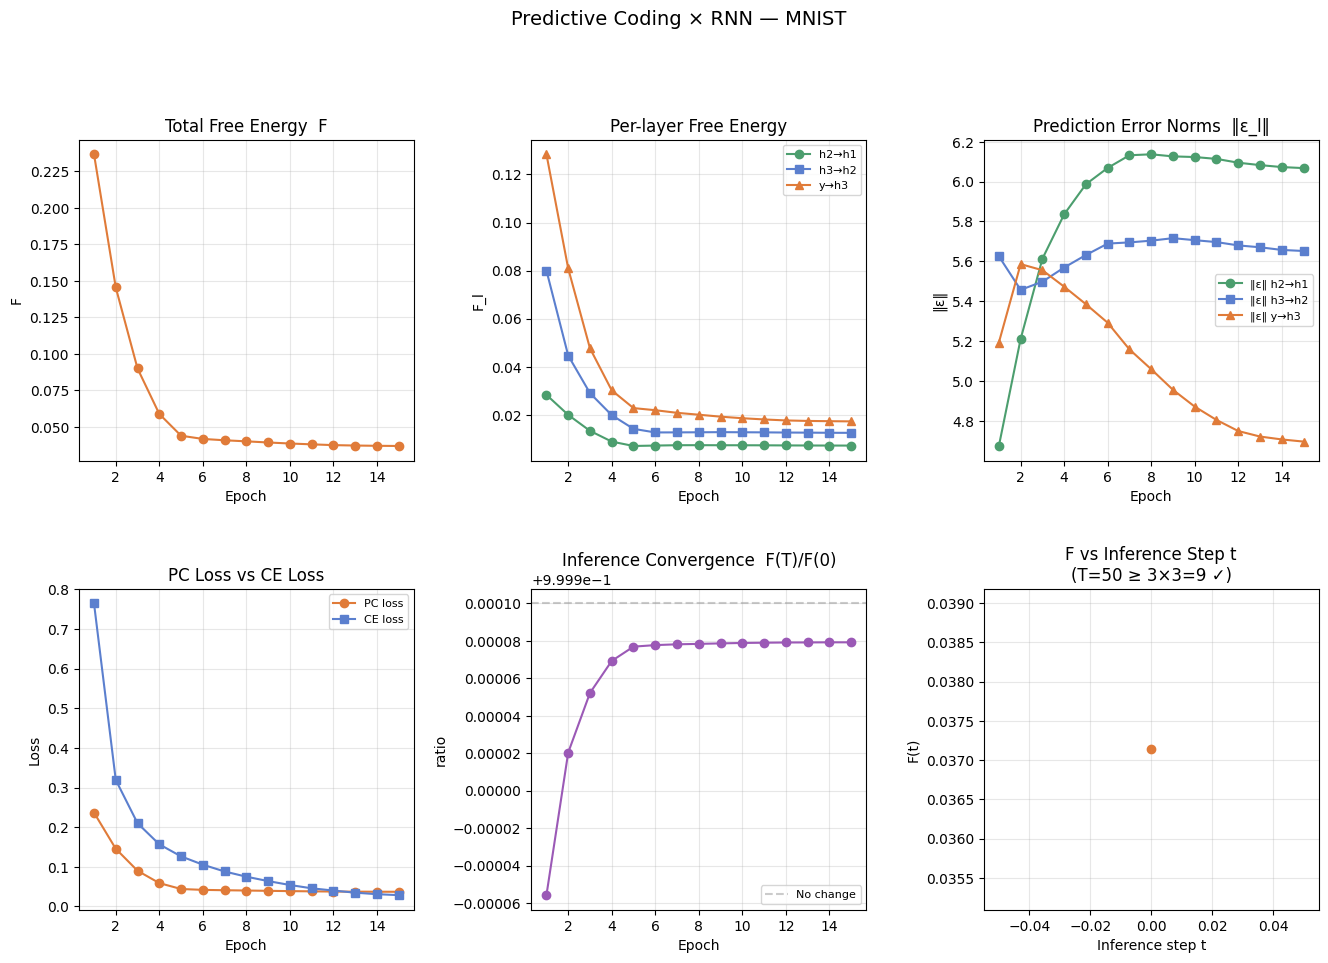

Saved pc_rnn_results.png


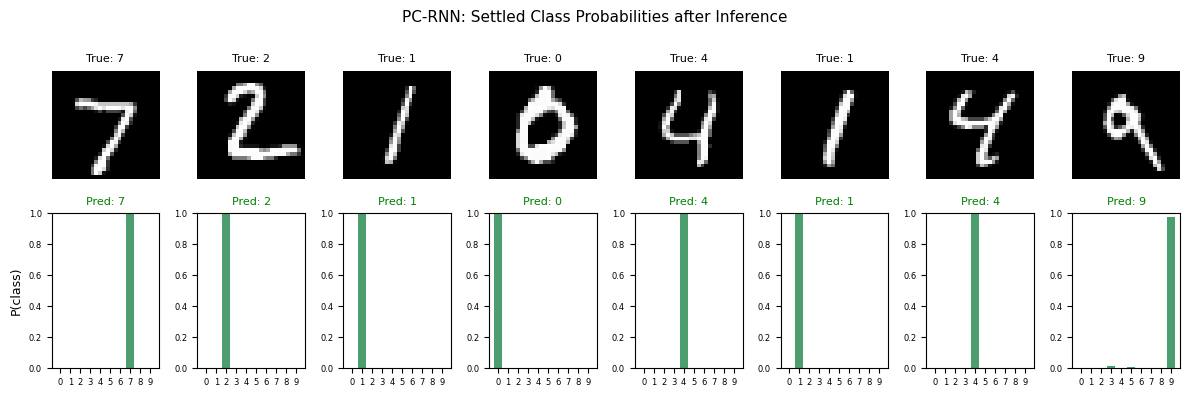

Saved pc_rnn_predictions.png

Model saved → pc_rnn_best.pt


In [34]:
def main():


    HIDDEN_SIZES       = [256, 128, 64]
    N_INFERENCE_STEPS  = 50          # T = 50 ≥ 3×3 = 9 ✓
    INFERENCE_LR       = 0.05
    CE_WEIGHT          = 1.0
    PC_WEIGHT          = 0.5
    WEIGHT_LR          = 5e-4
    BATCH_SIZE         = 256
    N_EPOCHS           = 15
    LOG_EVERY          = 50
    TRACK_CONV_EVERY   = 100

    print("═" * 65)
    print("  Predictive Coding × RNN  —  MNIST Classification")
    print("═" * 65)
    print(f"  Architecture  : RNN  {[28]+HIDDEN_SIZES}  (3 layers)")
    print(f"  PC nodes      : h1[{HIDDEN_SIZES[0]}] h2[{HIDDEN_SIZES[1]}] h3[{HIDDEN_SIZES[2]}] y[10]")
    print(f"  PC connections: 3  (h2→h1, h3→h2, y→h3)")
    print(f"  T_inf         : {N_INFERENCE_STEPS}  ≥  3×3={9}  ✓")
    print(f"  Inference lr  : {INFERENCE_LR}")
    print(f"  Weight lr     : {WEIGHT_LR} (Adam)")
    print(f"  CE / PC weight: {CE_WEIGHT} / {PC_WEIGHT}")
    print(f"  Batch size    : {BATCH_SIZE}")
    print(f"  Epochs        : {N_EPOCHS}")
    print("═" * 65 + "\n")

    train_loader, test_loader = get_loaders(BATCH_SIZE)

    model = PCRNNNet(
        input_size         = 28,
        hidden_sizes       = HIDDEN_SIZES,
        n_classes          = 10,
        inference_lr       = INFERENCE_LR,
        n_inference_steps  = N_INFERENCE_STEPS,
        ce_weight          = CE_WEIGHT,
        pc_weight          = PC_WEIGHT,
    ).to(DEVICE)

    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

    # Separate LR groups
    precision_params = [pc_l.log_precision for pc_l in model.pc_layers]
    other_params     = [p for n, p in model.named_parameters()
                        if "log_precision" not in n]

    opt = torch.optim.Adam([
        {"params": other_params,     "lr": WEIGHT_LR},
        {"params": precision_params, "lr": WEIGHT_LR * 10},  # faster precision updates
    ], weight_decay=1e-5)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_EPOCHS, eta_min=1e-6
    )

    # Training
    history = {
        "F_total": [], "F_h2→h1": [], "F_h3→h2": [], "F_y→h3": [],
        "E_h2→h1": [], "E_h3→h2": [], "E_y→h3": [], # Changed keys here from ‖ε‖_ to E_
        "pc_loss": [], "ce_loss": [], "total_loss": [],
        "ratio": [], "test_acc": [],
    }
    all_conv_snapshots = []
    best_acc = 0.0

    for epoch in range(1, N_EPOCHS + 1):
        print(f"\n{'═'*65}")
        print(f"  EPOCH {epoch}/{N_EPOCHS}")
        print(f"{'═'*65}")

        avg_metrics, conv_snaps = train_epoch(
            model, train_loader, opt, epoch,
            log_every        = LOG_EVERY,
            track_conv_every = TRACK_CONV_EVERY,
        )
        scheduler.step()

        test_acc = evaluate(model, test_loader)
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), "pc_rnn_best.pt")

        all_conv_snapshots.extend(conv_snaps)

        # Record history
        for k in history:
            if k == "test_acc":
                history[k].append(test_acc)
            elif k in avg_metrics:
                history[k].append(avg_metrics[k])

        print(f"\n  ▶ Test accuracy : {test_acc:.2f}%   (best: {best_acc:.2f}%)")
        print(f"    Free energy   : {avg_metrics.get('F_total', 0):.4f}")
        print(f"    Convergence   : {avg_metrics.get('ratio', 1):.3f}  (F(T)/F(0))")

    # final summary
    print_final_metrics(model, best_acc, history)

    # Plots

    history["test_acc_plot"] = history["test_acc"]   # alias for plot_all
    plot_all(history, all_conv_snapshots, model)
    visualise_reconstructions(model, test_loader)

    print(f"\nModel saved → pc_rnn_best.pt")


if __name__ == "__main__":
    main()